In [12]:
import yaml
import numpy as np
from TraceSimulator import LongTraceSimulator
import matplotlib.pyplot as plt


def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/ceph/dwong/delight_conf/ETP_config_v2.yaml')
lts = LongTraceSimulator(config)
def plot_traces(traces, fs=3_906_250, offset_step=70, title="QP Traces"):
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    plt.figure(figsize=(18, 12))
    
    for i in range(num_channels):
        color = 'orange' if i > 18 else 'tab:blue'
        plt.plot(time_ms, traces[i] + i * offset_step, lw=0.3, color=color)

    plt.xlabel("Time [ms]", fontsize=16)
    plt.ylabel("Offset ADC counts", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xlim(0, time_ms[-1])
    plt.ylim(-10, offset_step * (num_channels + 1))
    plt.yticks([])  # Hide y-axis ticks

    plt.tight_layout()
    plt.show()

In [16]:
trace, signal_mask= lts.generate(
            E=20,
            x=0,
            y=0,
            z=-1700,
            no_noise=False,
            type_recoil='NR',
            quantize=True,
            phonon_only=False,
            return_signal_mask=True
        )

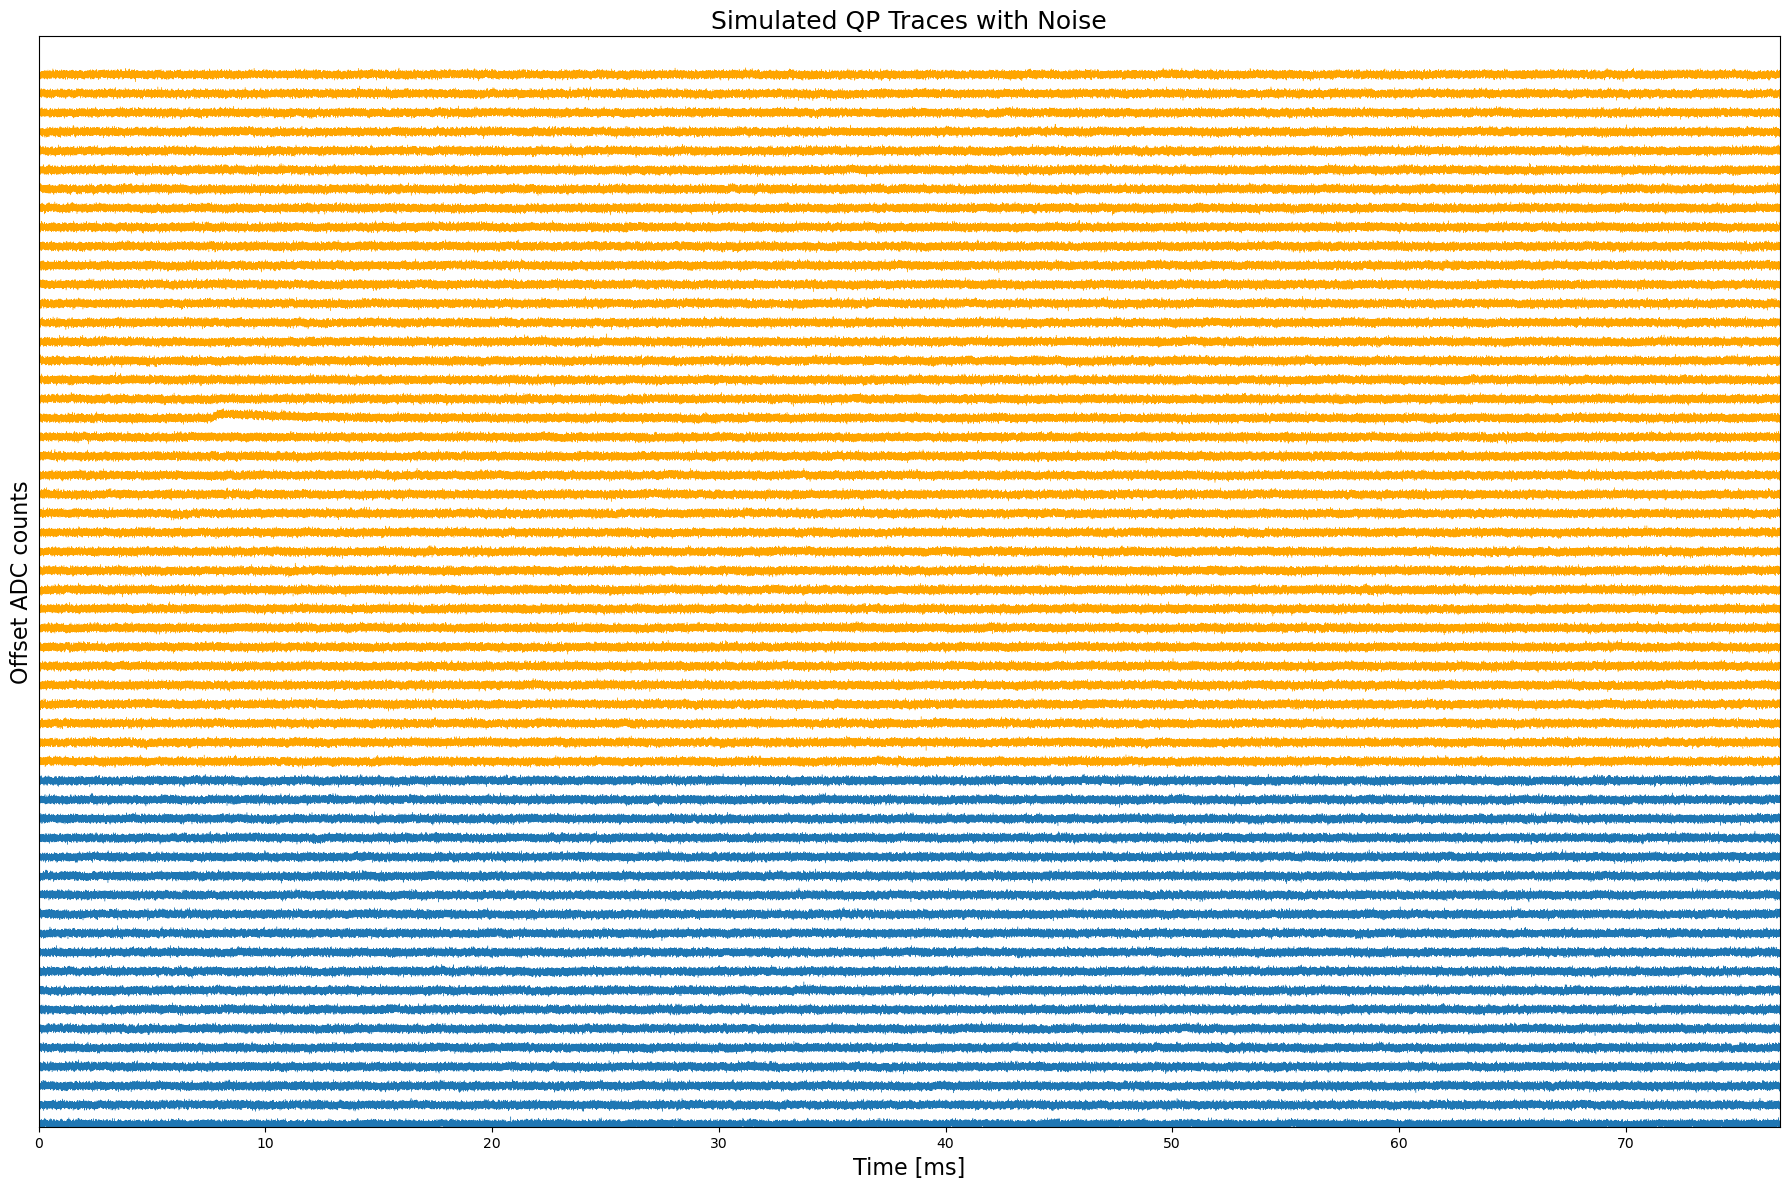

In [17]:
plot_traces(trace, title="Simulated QP Traces with Noise")

In [21]:
vac_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/vac_ch_template.npy")
noise_psd = np.load("/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy")
noise_psd_sum = 37 * noise_psd

fs = 3906250
from OptimumFilter import *
vac_of = OptimumFilter(vac_template, noise_psd, fs)
sum_of = OptimumFilter(vac_template, noise_psd_sum, fs)

In [24]:
trace = trace[0]

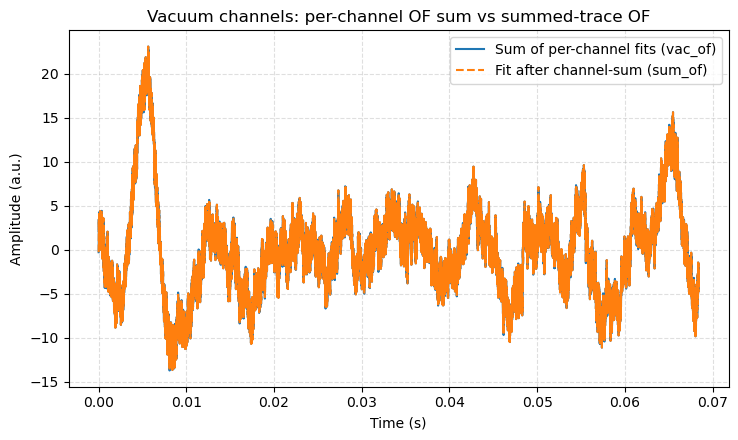

Peak (per-channel sum) = 23.08 at 0.005650 s
Peak (sum then fit)    = 23.08 at 0.005650 s


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Inputs you already have
# ---------------------------
# vac_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/vac_ch_template.npy")
# noise_psd = np.load("/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy")
# noise_psd_sum = 37 * noise_psd
# fs = 3906250
# from OptimumFilter import *
# vac_of = OptimumFilter(vac_template, noise_psd, fs)
# sum_of = OptimumFilter(vac_template, noise_psd_sum, fs)

# ---------------------------
# Helper: run both strategies on one multi-channel trace
# target_trace shape MUST be (n_channels, n_samples)
# ---------------------------
def compare_vac_filters(target_trace, vac_of, sum_of, fs, n_vac=37):
    if target_trace.ndim != 2:
        raise ValueError(f"target_trace must be 2D (n_channels, n_samples), got {target_trace.shape}")

    n_channels, n_samples = target_trace.shape
    if n_channels < n_vac:
        raise ValueError(f"Trace has {n_channels} channels but need at least {n_vac} vacuum channels")

    vac_idx = np.arange(n_channels - n_vac, n_channels)

    # 1) Fit each vacuum channel individually, sum amplitudes element-wise
    amp_list = []
    for ch in vac_idx:
        ampl_ch, chisq_ch = vac_of.sliding_fit(target_trace[ch])
        amp_list.append(ampl_ch)
    amp_sum_of_individuals = np.sum(amp_list, axis=0)  # shape: (n_windows,) — matches sliding_fit output length

    # 2) Sum all vacuum channels first, then fit once with sum_of
    vac_sum_trace = np.sum(target_trace[vac_idx, :], axis=0)
    amp_sumfit, chisq_sumfit = sum_of.sliding_fit(vac_sum_trace)

    # Time axis (seconds) for plotting — same length as sliding_fit amplitude arrays
    # If sliding_fit downsamples/strides internally, both methods produce same length by construction above.
    t = np.arange(amp_sumfit.shape[0]) / fs

    return t, amp_sum_of_individuals, amp_sumfit

# ---------------------------
# Example usage on one event trace
# ---------------------------
# target_trace = <your array, shape (n_channels, n_samples)>
t, amp_sum_of_individuals, amp_sumfit = compare_vac_filters(trace, vac_of, sum_of, fs, n_vac=37)

# ---------------------------
# Plot both on the same figure
# ---------------------------
plt.figure(figsize=(7.5, 4.5))
plt.plot(t, amp_sum_of_individuals, label="Sum of per-channel fits (vac_of)", alpha=0.5)
plt.plot(t, amp_sumfit, label="Fit after channel-sum (sum_of)", linestyle="--", alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u.)")
plt.title("Vacuum channels: per-channel OF sum vs summed-trace OF")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# (Optional) quick comparison of peaks
idx1 = int(np.argmax(amp_sum_of_individuals))
idx2 = int(np.argmax(amp_sumfit))
print(f"Peak (per-channel sum) = {amp_sum_of_individuals[idx1]:.4g} at {t[idx1]:.6f} s")
print(f"Peak (sum then fit)    = {amp_sumfit[idx2]:.4g} at {t[idx2]:.6f} s")



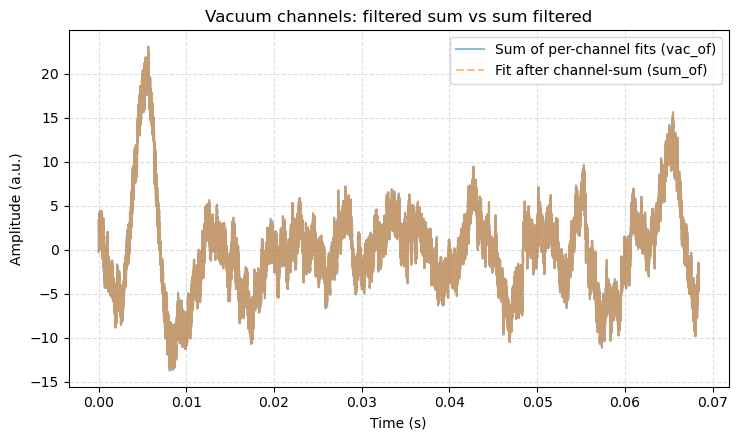

Peak (per-channel sum) = 23.08 at 0.005650 s
Peak (sum then fit)    = 23.08 at 0.005650 s


In [27]:
plt.figure(figsize=(7.5, 4.5))
plt.plot(t, amp_sum_of_individuals, label="Sum of per-channel fits (vac_of)", alpha=0.5)
plt.plot(t, amp_sumfit, label="Fit after channel-sum (sum_of)", linestyle="--", alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u.)")
plt.title("Vacuum channels: filtered sum vs sum filtered")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# (Optional) quick comparison of peaks
idx1 = int(np.argmax(amp_sum_of_individuals))
idx2 = int(np.argmax(amp_sumfit))
print(f"Peak (per-channel sum) = {amp_sum_of_individuals[idx1]:.4g} at {t[idx1]:.6f} s")
print(f"Peak (sum then fit)    = {amp_sumfit[idx2]:.4g} at {t[idx2]:.6f} s")


In [2]:
import numpy as np
ampl = np.load("/ceph/dwong/trigger_samples/v2_300k_rand/max_amp_rand/vacuum_metrics_energy_20.npy")

In [3]:
ampl

array([[15.76739638, 15.76739638],
       [12.67408583, 12.67408583],
       [18.37015883, 18.37015883],
       [13.35697497, 13.35697497],
       [10.49323754, 10.49323754],
       [13.59935318, 13.59935318],
       [16.63701631, 16.63701631],
       [13.89457593, 13.89457593],
       [11.18219722, 11.18219722],
       [13.22115783, 13.22115783],
       [12.06878483, 12.06878483],
       [12.35085993, 12.35085993],
       [10.22298487, 10.22298487],
       [15.62572054, 15.62572054],
       [15.72237968, 15.72237968],
       [ 8.32900835,  8.32900835],
       [13.06401654, 13.06401654],
       [13.27195463, 13.27195463],
       [10.46026558, 10.46026558],
       [17.87562414, 17.87562414],
       [15.46444498, 15.46444498],
       [ 9.7504662 ,  9.7504662 ],
       [12.17443005, 12.17443005],
       [17.00962368, 17.00962368],
       [10.92067315, 10.92067315],
       [15.62491852, 15.62491852],
       [14.34463298, 14.34463298],
       [10.11739823, 10.11739823],
       [12.00258062,

[warn] missing file: /ceph/dwong/trigger_samples/v2_300k_rand/max_amp_rand/vacuum_metrics_energy_1.npy
[warn] missing file: /ceph/dwong/trigger_samples/v2_300k_rand/max_amp_rand/vacuum_metrics_energy_3.npy
[warn] missing file: /ceph/dwong/trigger_samples/v2_300k_rand/max_amp_rand/vacuum_metrics_energy_5.npy
[warn] missing file: /ceph/dwong/trigger_samples/v2_300k_rand/max_amp_rand/vacuum_metrics_energy_7.npy
[warn] missing file: /ceph/dwong/trigger_samples/v2_300k_rand/max_amp_rand/vacuum_metrics_energy_9.npy
[warn] missing file: /ceph/dwong/trigger_samples/v2_300k_rand/max_amp_rand/vacuum_metrics_energy_11.npy
[warn] missing file: /ceph/dwong/trigger_samples/v2_300k_rand/max_amp_rand/vacuum_metrics_energy_13.npy
[warn] missing file: /ceph/dwong/trigger_samples/v2_300k_rand/max_amp_rand/vacuum_metrics_energy_15.npy
[warn] missing file: /ceph/dwong/trigger_samples/v2_300k_rand/max_amp_rand/vacuum_metrics_energy_17.npy
[warn] missing file: /ceph/dwong/trigger_samples/v2_300k_rand/max_amp

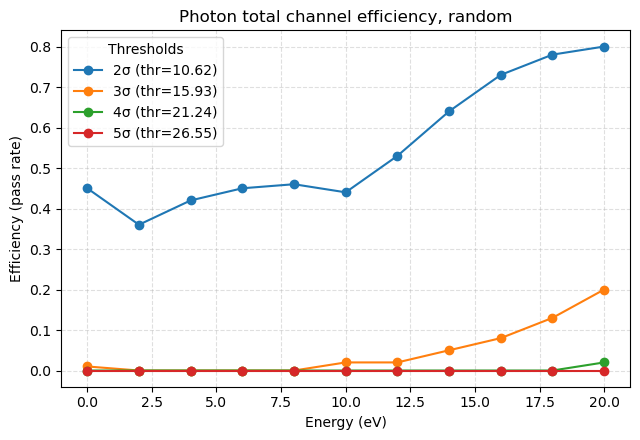


Pass rates:
Energy    2σ(thr=10.62)   3σ(thr=15.93)   4σ(thr=21.24)   5σ(thr=26.55)
0                0.4500         0.0100         0.0000         0.0000
2                0.3600         0.0000         0.0000         0.0000
4                0.4200         0.0000         0.0000         0.0000
6                0.4500         0.0000         0.0000         0.0000
8                0.4600         0.0000         0.0000         0.0000
10               0.4400         0.0200         0.0000         0.0000
12               0.5300         0.0200         0.0000         0.0000
14               0.6400         0.0500         0.0000         0.0000
16               0.7300         0.0800         0.0000         0.0000
18               0.7800         0.1300         0.0000         0.0000
20               0.8000         0.2000         0.0200         0.0000


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Config ---
base = Path("/ceph/dwong/trigger_samples/v2_300k_rand/max_amp_rand")
file_tmpl = "vacuum_metrics_energy_{E}.npy"
energies = range(0, 21)                # 0..20 inclusive
sigma = 5.31
sigma_multiples = [2, 3, 4, 5]         # thresholds in units of sigma

# --- Thresholds dict in your style ---
thresholds = {k: k * sigma for k in sigma_multiples}

# --- Collect pass rates per energy ---
available_E = []
pass_rates = {k: [] for k in sigma_multiples}

def load_first_column(path: Path):
    arr = np.load(path)
    if arr.ndim == 2 and arr.shape[1] >= 1:
        return arr[:, 0]
    elif arr.ndim == 1:
        return arr
    else:
        raise ValueError(f"Unexpected shape {arr.shape} in {path}")

for E in energies:
    fpath = base / file_tmpl.format(E=E)
    try:
        amps = load_first_column(fpath)
    except FileNotFoundError:
        print(f"[warn] missing file: {fpath}")
        continue

    available_E.append(E)
    for k in sigma_multiples:
        thr = thresholds[k]
        rate = (amps >= thr).mean()  # use '>' if you prefer strict
        pass_rates[k].append(rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for k in sigma_multiples:
    thr = thresholds[k]
    label = f"{k}σ (thr={thr:.2f})"
    plt.plot(available_E, pass_rates[k], marker="o", label=label)

plt.xlabel("Energy (eV)")
plt.ylabel("Efficiency (pass rate)")
plt.title(f"Photon total channel efficiency, random")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --- (Optional) print a small table ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join([f"{k}σ(thr={thresholds[k]:.2f})".rjust(14) for k in sigma_multiples])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for k in sigma_multiples:
        row.append(f"{pass_rates[k][i]:>14.4f}")
    print(" ".join(row))
